# Load deps

In [ ]:
# ! pip install -q torcheval

In [ ]:
# # # if src modules imported
# # from google.colab import drive
# # drive.mount('/content/drive')
# import sys
# app_path = '/content/drive/MyDrive/Projects/miniSD'
# sys.path.append(app_path)

In [ ]:
import torch, os
import matplotlib as mpl
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from datasets import load_dataset
from diffusers import UNet2DModel, DDIMScheduler, DDPMScheduler
import torchvision.transforms.functional as TF
import torch.nn.functional as F
from torch import tensor
from types import SimpleNamespace

from src.datasets import inplace, DataLoaders, show_images
from src.conv import def_device
from src.learner import DeviceCB
from src.fid import ImageEval

# Config

In [ ]:
mpl.rcParams['image.cmap'] = 'gray_r'
torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
num_dl_workers = os.cpu_count()
dataset_xl,dataset_yl = 'image','label'
dataset_name = "fashion_mnist"
n_steps = 1000
bs = 512
n_samples = bs
# lr = 1e-2
# epochs = 10
betamax=0.01 # the same value used during training
models_path = Path("artifacts/models")
assert models_path.exists(), "must upload artifacts folder first"

# Load dataset

In [ ]:
dsd = load_dataset(dataset_name)
@inplace
def transformi(b):
    b[dataset_xl] = [
        F.pad(TF.to_tensor(o), (2,2,2,2))*2-1
        for o in b[dataset_xl]
    ]

tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs, num_workers=num_dl_workers)

dt = dls.train
xb,yb = next(iter(dt))

# Load model
- pre-trained fashion-mnist-DDPM model

In [ ]:
class UNet(UNet2DModel): pass
    # def forward(self, x): return super().forward(*x).sample
# we don't override the forward method
# because we're going to use schedulers from diffusers library
# and those diffusers don't assume the default forward model

model = UNet(
    in_channels=1, out_channels=1,
    block_out_channels=(32, 64, 128, 256), norm_num_groups=8
)
checkpoint_path = models_path / 'fashion_ddpm3_mp_ts_1000.pkl'
model_art = torch.load(checkpoint_path, weights_only=False).cuda();
model.load_state_dict(model_art.state_dict());
model.to(def_device);

# Sampling with Diffusers DDPM Scheduler

## A single step

In [ ]:
sched = DDPMScheduler(beta_end=betamax)
x_t = torch.randn((32,1,32,32)).cuda()
t = 999
t_batch = torch.full((len(x_t),), t, device=x_t.device, dtype=torch.long)
with torch.no_grad(): noise = model(x_t, t_batch).sample
res = sched.step(noise, t, x_t) # calulate x_t given t and noise
print(res.prev_sample.shape)

## A sampling loop

In [ ]:
sz = (n_samples,1,32,32)
x_t = torch.randn(sz).cuda()
# an interesting point is that even though we train and sample from the model with input range of [-0.5, 0.5]
# we don't scale the initial noise acordingly. neither for training nor for sampling
# TODO: what happens if we do?
preds = []
from fastprogress.fastprogress import progress_bar
for t in progress_bar(sched.timesteps):
    with torch.no_grad(): noise = model(x_t, t).sample
    x_t = sched.step(noise, t, x_t).prev_sample
    preds.append(x_t.float().cpu())

In [ ]:
s = preds[-1].clamp(-0.5,0.5)*2
# re-scale the input from [-0.5, 0.5] to [-1,1] 
# becuse the reference model expects this range.
show_images(s[:16], imsize=1.5);

# Image genertion performance measurement 

## Load the reference model

In [ ]:
from torch import distributions, nn
from src.init import GeneralRelu, init_weights
from src.resnet import ResBlock
from src.augment import capture_preds
from functools import partial
# TODO: we use this import to patch the capture_preds to the `Learner` class
# this is not a good practice at all. change it ASAP

class Dropout(nn.Module):
    def __init__(self, p=0.1):
        super().__init__()
        self.p = p

    def forward(self, x):
        if not self.training: return x
        dist = distributions.binomial.Binomial(tensor(1.0).to(x.device), probs=1-self.p)
        return x * dist.sample(x.size()) * 1/(1-self.p)

def get_dropmodel(
    act=nn.ReLU,
    nfs=(16,32,64,128,256,512),
    norm=nn.BatchNorm2d,
    drop=0.0
):
    layers = [
        ResBlock(1, 16, ks=5, stride=1, act=act, norm=norm),
        nn.Dropout2d(drop)
    ]
    layers += [
        ResBlock(nfs[i], nfs[i+1], act=act, norm=norm, stride=2)
        for i in range(len(nfs)-1)
    ]
    layers += [
        nn.Flatten(),
        Dropout(drop),
        nn.Linear(nfs[-1], 10, bias=False),
        nn.BatchNorm1d(10)
    ]
    return nn.Sequential(*layers)

act_gr = partial(GeneralRelu, leak=0.1, sub=0.4)
iw = partial(init_weights, leaky=0.1)
cmodel = get_dropmodel(act_gr, norm=nn.BatchNorm2d, drop=0.1).apply(iw)
loaded_art = torch.load(models_path / 'data_aug2.pkl', weights_only=False)
cmodel.load_state_dict(loaded_art.state_dict())
cmodel = cmodel[:-3] # the desired feature head

In [ ]:
ie = ImageEval(cmodel, dls, cbs=[DeviceCB()])

In [ ]:
print(f"sampled images fid: {ie.fid(s)}, kid: {ie.kid(s)}")
# the real image batches are already in [-1,1] range
print(f"real images fid: {ie.fid(xb)}, kid: {ie.kid(xb)}")

# Sampling with Diffusers DDIM Scheduler

In [ ]:
sched = DDIMScheduler(beta_end=betamax)
sched.set_timesteps(333)

def diff_sample(model, sz, sched, **kwargs):
    x_t = torch.randn(sz).cuda()
    preds = []
    for t in progress_bar(sched.timesteps):
        with torch.no_grad(): noise = model(x_t, t).sample
        x_t = sched.step(noise, t, x_t, **kwargs).prev_sample
        preds.append(x_t.float().cpu())
    return preds

In [ ]:
preds = diff_sample(model, sz, sched, eta=1.)
# eta controls how much nise to add

In [ ]:
s = (preds[-1]*2).clamp(-1,1)
# show_images(s[:25], imsize=1.5);
print(f"sampled images fid: {ie.fid(s)}, kid: {ie.kid(s)}")
print(f"real images fid: {ie.fid(xb)}, kid: {ie.kid(xb)}")

In [ ]:
sched.set_timesteps(200)
preds = diff_sample(model, sz, sched, eta=1.)
s = (preds[-1]*2).clamp(-1,1)
print(f"sampled images fid: {ie.fid(s)}, kid: {ie.kid(s)}")
print(f"real images fid: {ie.fid(xb)}, kid: {ie.kid(xb)}")

In [ ]:
sched.set_timesteps(100)
preds = diff_sample(model, sz, sched, eta=1.)
s = (preds[-1]*2).clamp(-1,1)
print(f"sampled images fid: {ie.fid(s)}, kid: {ie.kid(s)}")
print(f"real images fid: {ie.fid(xb)}, kid: {ie.kid(xb)}")

In [ ]:
sched.set_timesteps(50)
preds = diff_sample(model, sz, sched, eta=1.)
s = (preds[-1]*2).clamp(-1,1)
print(f"sampled images fid: {ie.fid(s)}, kid: {ie.kid(s)}")
print(f"real images fid: {ie.fid(xb)}, kid: {ie.kid(xb)}")

In [ ]:
sched.set_timesteps(25)
preds = diff_sample(model, sz, sched, eta=1.)
s = (preds[-1]*2).clamp(-1,1)
print(f"sampled images fid: {ie.fid(s)}, kid: {ie.kid(s)}")
print(f"real images fid: {ie.fid(xb)}, kid: {ie.kid(xb)}")

# Implementing DDIM Sampler

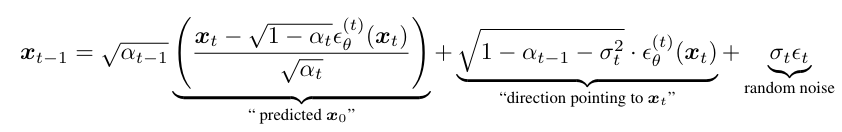

In [ ]:
def linear_sched(betamin=0.0001,betamax=betamax,n_steps=n_steps):
    beta = torch.linspace(betamin, betamax, n_steps)
    return SimpleNamespace(a=1.-beta, abar=(1.-beta).cumprod(dim=0), sig=beta.sqrt())

def ddim_step(x_t, t, noise, abar_t, abar_t1, bbar_t, bbar_t1, eta):
    vari = ((bbar_t1/bbar_t) * (1-abar_t/abar_t1))
    sig = vari.sqrt()*eta
    x_0_hat = ((x_t-bbar_t.sqrt()*noise) / abar_t.sqrt())
    x_t = abar_t1.sqrt()*x_0_hat + (bbar_t1-sig**2).sqrt()*noise
    if t>0: x_t += sig * torch.randn(x_t.shape).to(x_t)
    return x_t

@torch.no_grad()
def sample(abar, step_func, model, sz, n_steps, skips=1, eta=1.):
    tsteps = list(reversed(range(0, n_steps, skips)))
    x_t = torch.randn(sz).to(model.device)
    preds = []
    for i,t in enumerate(progress_bar(tsteps)):
        abar_t1 = abar[tsteps[i+1]] if t > 0 else torch.tensor(1)
        noise = model(x_t,t).sample
        x_t = step_func(x_t, t, noise, abar[t], abar_t1, 1-abar[t], 1-abar_t1, eta)
        preds.append(x_t.float().cpu())
    return preds

In [ ]:
sc = linear_sched()
samples = sample(sc.abar, ddim_step, model, sz, 1000, 10)

In [ ]:
s = (samples[-1]*2)#.clamp(-1,1)
# show_images(s[:25], imsize=1.5)
print(f"sampled images fid: {ie.fid(s)}, kid: {ie.kid(s)}")
print(f"real images fid: {ie.fid(xb)}, kid: {ie.kid(xb)}")